In [1]:
import collections
from IPython import display
import matplotlib.pyplot as plt

import numpy as np
import torch
import itertools as itr
from torch import nn
from common.ffn.ffn_relu import ParametricReLUNet
from common.coeff_calc.coeff_calc_ntk import NTKSimulator

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from util import *
import logging

In [2]:
logging.basicConfig(filename="log_ntk_minst.log",
                level=logging.WARN,
                format='%(levelname)s: %(asctime)s %(message)s',
                datefmt='%m/%d/%Y %I:%M:%S')

In [3]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = MNIST(root='./', train=True, download=True, transform=image_transform)
test_dataset = MNIST(root='./', train=False, download=True, transform=image_transform)

In [4]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

In [5]:
class MNISTReLU(ParametricReLUNet):
    def __init__(self, input_dim, output_dim):
        super().__init__(n0=input_dim,nk=0,nl=output_dim,l=0, bias_on=True)

        self.input_fc = nn.Linear(input_dim, 250)
        self.hidden_fc = nn.Linear(250, 100)
        self.output_fc = nn.Linear(100, output_dim)

    def forward_(self, x):
        return self.forward(x)

    def forward(self, x):
        #x = [batch size, height, width]
        #x = [batch size, height * width]
        h_1 = self.PReLU(self.input_fc(x))
        #h_1 = [batch size, 250]
        h_2 = self.PReLU(self.hidden_fc(h_1))
        #h_2 = [batch size, 100]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred
    
    def init_weights(self, cb=0.0, cw=1.0):
        if self.get_log_level() == "debug":
            print("FeedForwardNet weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        self.init_linear_weights(self.input_fc, self.bias_on, cb, cw/self.input_fc.in_features)
        self.init_linear_weights(self.hidden_fc, self.bias_on, cb, cw/self.hidden_fc.in_features)
        self.init_linear_weights(self.output_fc, self.bias_on, cb, cw/self.output_fc.in_features)


In [6]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 10  # num classes

lb, lw, ln = 1e-2, 1e-1, 3 #1e-2,1,1 #1e-2, 1e-2, 1
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)


FeedForwardNet created with n0=784, nk=0, nl=10, l=0, bias_on=True


#### NTK by formulas (10.44) and (10.45)

In [7]:
images, labels = next(iter(train_dataloader))
#images = [batch_size, height, width]
batch_size = images.shape[0]
xx = images.view(batch_size, -1)

def PReLUz(input: float) -> float:
    return slope_plus * input if input >= 0 else slope_minus * input

def PReLUdrv(input: float) -> float:
    return slope_plus if input >= 0 else slope_minus

act = np.vectorize(PReLUz)
drv = np.vectorize(PReLUdrv)

KK = np.zeros((ln, BATCH_SIZE, BATCH_SIZE))
Theta = np.zeros_like(KK)
sim = NTKSimulator(cb=cb, cw=cw, lb=lb, lw=lw, act=act, drv=drv, n_samples=2_000_000)
sim.calculate_layer0(KK, Theta, np.transpose(xx.detach().numpy()))
for idx in range(1, ln):
    sim.calculate_layer(KK, Theta, idx)
    print('-', end='')

thetaL = Theta[-1]

--

#### NTK by formulas (8.4)

In [8]:
#lambdas as from (8.5)
lw_input, lw_hidden, lw_output = lw/INPUT_DIM, lw/250, lw/100

logits = testNet.forward_(xx)

print("Calculating derivatives")
input_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, 250, INPUT_DIM))
input_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, 250))
hidden_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, 100, 250))
hidden_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, 100))
output_fc_weight = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM, 100))
output_fc_bias = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM))

for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
    df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                    , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                    , testNet.output_fc.weight, testNet.output_fc.bias)\
        , retain_graph=True, create_graph=True, allow_unused=True)
    input_fc_weight[kk, alpha] = df[0].detach().numpy()
    input_fc_bias[kk, alpha] = df[1].detach().numpy()
    hidden_fc_weight[kk, alpha] = df[2].detach().numpy()
    hidden_fc_bias[kk, alpha] = df[3].detach().numpy()
    output_fc_weight[kk, alpha] = df[4].detach().numpy()
    output_fc_bias[kk, alpha] = df[5].detach().numpy()

print("Calculating NTK by (8.4)")
HL = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
for kk1, kk2, alpha1, alpha2 in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)\
                                            , range(BATCH_SIZE), range(BATCH_SIZE)):
    HL[kk1, kk2, alpha1, alpha2] += lb * np.dot(input_fc_bias[kk1, alpha1], input_fc_bias[kk2, alpha2])
    HL[kk1, kk2, alpha1, alpha2] += \
        lw_input * np.sum(np.multiply(input_fc_weight[kk1, alpha1], input_fc_weight[kk2, alpha2]))
    HL[kk1, kk2, alpha1, alpha2] += lb * np.dot(hidden_fc_bias[kk1, alpha1], hidden_fc_bias[kk2, alpha2])
    HL[kk1, kk2, alpha1, alpha2] += \
        lw_hidden * np.sum(np.multiply(hidden_fc_weight[kk1, alpha1], hidden_fc_weight[kk2, alpha2]))
    HL[kk1, kk2, alpha1, alpha2] += lb * np.dot(output_fc_bias[kk1, alpha1], output_fc_bias[kk2, alpha2])
    HL[kk1, kk2, alpha1, alpha2] += \
        lw_output * np.sum(np.multiply(output_fc_weight[kk1, alpha1], output_fc_weight[kk2, alpha2]))

print("Calculating averages and variances")
HL_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
HL_var, HLNDG_avg, HLNDG_var = np.zeros_like(HL_avg), np.zeros_like(HL_avg), np.zeros_like(HL_avg)

for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
    data = [HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)]
    HL_avg[alpha1, alpha2] = np.average(data)
    HL_var[alpha1, alpha2] = np.var(data, ddof=1)
    data2 = [HL[num1, num2, alpha1, alpha2] for num1, num2 in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)) if num1 != num2]
    HLNDG_avg[alpha1, alpha2] = np.average(data2)
    HLNDG_var[alpha1, alpha2] = np.var(data2, ddof=1)


Calculating derivatives
Calculating NTK by (8.4)
Calculating averages and variances


In [9]:
print("For NTK calculated by (8.4) and averaged for i_1=i_2:\n max(abs)={}, avg(abs)={}".\
      format(np.max(np.abs(HL_avg)), np.average(np.abs(HL_avg))))
print("For delta between NTK calculated by (8.4)/averaged for i_1=i_2 and NTK calculated by (10.44)-(10.45):\n max(abs(Δ))={}, avg(abs(Δ))={}".\
      format(np.max(np.abs(HL_avg - thetaL)), np.average(np.abs(HL_avg - thetaL))))
print("For NTK calculated by (8.4) for non-diagonal elements i_1!=i_2:\n min={}, max={}, avg={}".\
      format(np.min(HLNDG_avg), np.max(HLNDG_avg), np.average(HLNDG_avg)))


For NTK calculated by (8.4) and averaged for i_1=i_2:
 max(abs)=0.08805331094341598, avg(abs)=0.03650805764380713
For delta between NTK calculated by (8.4)/averaged for i_1=i_2 and NTK calculated by (10.44)-(10.45):
 max(abs(Δ))=0.01344431174683032, avg(abs(Δ))=0.0029740679589604887
For NTK calculated by (8.4) for non-diagonal elements i_1!=i_2:
 min=-0.001215936441727758, max=0.0013948975732461471, avg=1.1344608919691266e-05


In [10]:
def rf(value):
    return f"{value:.5f}"

report = np.zeros((4,4), dtype='U256')
for row, col in itr.product(range(4), range(4)):
    report[row, col] = "NTK(8.4) for diagonal elements: avg="+rf(HL_avg[row, col])\
        +", var="+rf(HL_var[row, col])+"\nNTK(10.45): "+rf(thetaL[row, col])+"\n"\
        +"NTK(8.4) for non-diagonal elements: avg="+rf(HLNDG_avg[row, col])+", var="+rf(HLNDG_var[row, col])


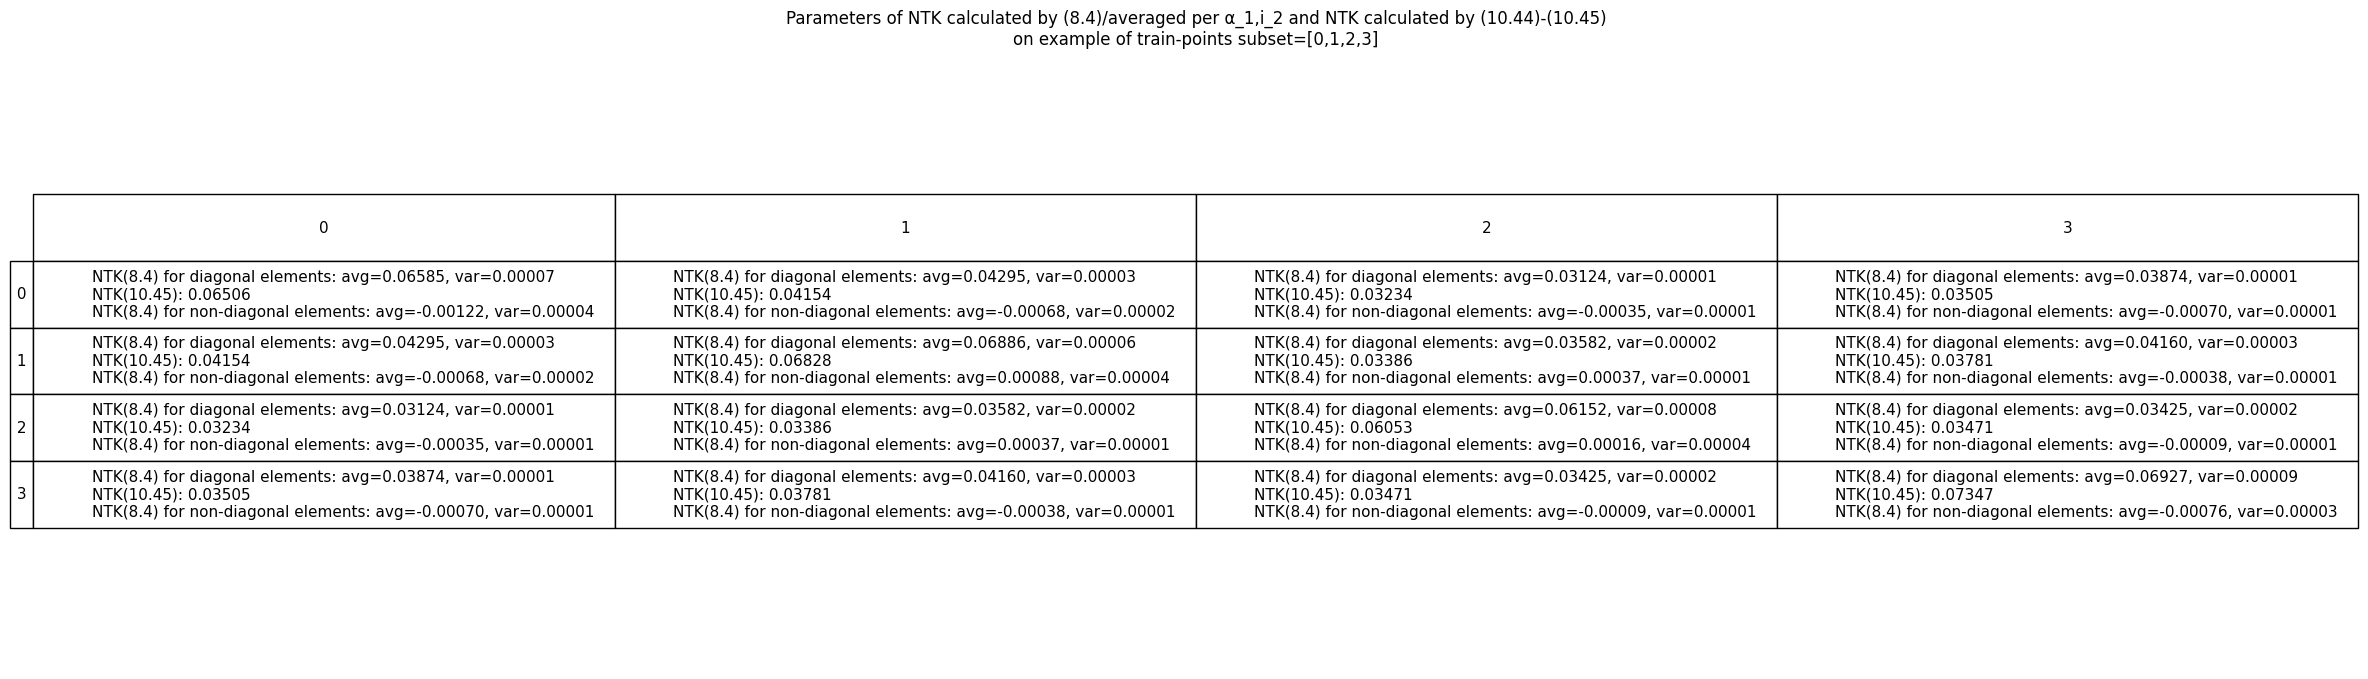

In [11]:

fig, ax = plt.subplots(figsize=(10, 8))

# hide axes
#fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

tab_plot = ax.table(cellText=report, colLabels=['0','1','2','3'], rowLabels=[' 0 ',' 1 ',' 2 ',' 3 '], cellLoc='left', loc='center')
tab_plot.auto_set_font_size(False)
tab_plot.set_fontsize(11)
tab_plot.scale(3, 4)
#fig.tight_layout()
ax.set_title('Parameters of NTK calculated by (8.4)/averaged per α_1,i_2 and NTK calculated by (10.44)-(10.45)\n'\
             +'on example of train-points subset=[0,1,2,3]')
plt.show()
